In [31]:
# getting ready 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
sns.set_theme(style='whitegrid', font_scale= 1.1)


In [32]:
# part 1 of project 
def outlier_info(df, cols):
    
    summary = {}
    
    for col in cols:
        
        Q1 = np.percentile(df[col].dropna(), 25)
        Q3 = np.percentile(df[col].dropna(), 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        count = ((df[col] < lower) | (df[col] > upper)).sum()
        summary[col] = count
    
    return pd.Series(summary)


def remove_outliers(df, cols):

    df_clean = df.copy()
    for col in cols:
        Q1 = np.percentile(df_clean[col].dropna(), 25)
        Q3 = np.percentile(df_clean[col].dropna(), 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean




In [33]:
# Part 2 
URL = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv'
df = pd.read_csv(URL)

print(f'Shape: {df.shape[0]} rows , {df.shape[1]} columns')
df.head()

Shape: 119390 rows , 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [34]:
#  Data info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [35]:
#  values count
print('         Missing Values ')
print('___________________________________')
print(df['hotel'].value_counts())
print('___________________________________')
print(df['meal'].value_counts())
print('___________________________________')
print(df['market_segment'].value_counts())
print('___________________________________')
print(df['deposit_type'].value_counts())
print('___________________________________')
print(df['customer_type'].value_counts())

         Missing Values 
___________________________________
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64
___________________________________
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64
___________________________________
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64
___________________________________
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64
___________________________________
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


In [36]:
# missing values
print("--------------------------------------------------")
print("          MISSING VALUES REPORT PER COLUMN        ")
print("--------------------------------------------------")

missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

print('---')
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %':     missing_pct
})

print(missing_summary[missing_summary['Missing Count'] > 0])

--------------------------------------------------
          MISSING VALUES REPORT PER COLUMN        
--------------------------------------------------
---
          Missing Count  Missing %
children              4   0.003350
country             488   0.408744
agent             16340  13.686238
company          112593  94.306893


In [37]:
# central tendency
df.describe().round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


In [38]:
#  Central tendency & spread 
numeric_cols = df.select_dtypes(include='number').columns.tolist()

numeric_cols = df.select_dtypes('number').columns.tolist()

stats_dict = {}

for col in numeric_cols:
    
    p25_value = np.percentile(df[col].dropna(), 25)
    p75_value = np.percentile(df[col].dropna(), 75)
    
    stats_dict[col] = {
        'mean':   round(df[col].mean(), 2),
        'median': round(df[col].median(), 2),
        'mode':   df[col].mode()[0],
        'std':    round(df[col].std(), 2),
        'p25':    round(p25_value, 2),
        'p75':    round(p75_value, 2)
    }

stats_df = pd.DataFrame(stats_dict).T #-> fliping rows and columns

stats_df

,mean,median,mode,std,p25,p75
is_canceled,0.37,0.00,0.0,0.48,0.00,1.0
lead_time,104.01,69.00,0.0,106.86,18.00,160.0
arrival_date_year,2016.16,2016.00,2016.0,0.71,2016.00,2017.0
arrival_date_week_number,27.17,28.00,33.0,13.61,16.00,38.0
arrival_date_day_of_month,15.80,16.00,17.0,8.78,8.00,23.0
stays_in_weekend_nights,0.93,1.00,0.0,1.00,0.00,2.0
stays_in_week_nights,2.50,2.00,2.0,1.91,1.00,3.0
adults,1.86,2.00,2.0,0.58,2.00,2.0
children,0.10,0.00,0.0,0.40,0.00,0.0
babies,0.01,0.00,0.0,0.10,0.00,0.0


In [ ]:
# categorical value counts 
print("=" * 35)
print("       categorical value counts")
print("=" * 35)

cat_cols = ['hotel', 'meal', 'market_segment', 'deposit_type', 'customer_type', 'reservation_status']

for col in cat_cols:
    print(f'\n-- {col} --')
    print(df[col].value_counts())

# numerical value counts
print("=" * 35)
print("       categorical value counts")
print("=" * 35)
numeric_cols = df.select_dtypes(include='number').columns.tolist()
for col in numeric_cols:
    print(f'\n-- {col} --')
    print(df[col].value_counts())

       categorical value counts

── hotel ──
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

── meal ──
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

── market_segment ──
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

── deposit_type ──
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

── customer_type ──
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

── reservation_status ──
reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64
       categorical value counts

── is_canceled ──
is_canceled
0    75166
1    4422

# Interpretation
* Dataset Scale: The dataset is quite large with 119,390 rows, which gives us a solid sample size to understand booking patterns and build a reliable model later.
* Price Variation adr The average price is around $101.83, but the high standard deviation of 50.54 shows that prices fluctuate a lot
* Booking Patterns lead_timeHalf of the customers book their rooms more than 69 days in advance (the median). However, the mean is over 100 days, meaning there are some large group or travel agency bookings made very early.
* High Cancellations is_canceled  Around 37% of the bookings end up canceled. This is a very high number for any hotel and represents a major revenue risk that needs fixing.

In [40]:
# missing values
print("--------------------------------------------------")
print("          MISSING VALUES REPORT PER COLUMN        ")
print("--------------------------------------------------")

missing_count = df.isnull().sum()
missing_pct = round(df.isnull().mean() * 100,2)

print('---')
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %':     missing_pct
})

print(missing_summary[missing_summary['Missing Count'] > 0])

--------------------------------------------------
          MISSING VALUES REPORT PER COLUMN        
--------------------------------------------------
---
          Missing Count  Missing %
children              4       0.00
country             488       0.41
agent             16340      13.69
company          112593      94.31


In [41]:
df = df.copy()

#  Handle missing values 

df['children'] = df['children'].fillna(df['children'].median())

df['country'] = df['country'].fillna(df['country'].mode()[0])

df['agent']   = df['agent'].fillna(df['agent'].median())

df = df.drop(columns=['reservation_status', 'reservation_status_date']) # for ML model expectation
print('Missing values after cleaning:')
print(df.isnull().sum().unique())
print(df.head())

Missing values after cleaning:
[     0 112593]
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
0                        0                     0    

In [42]:
#  Remove duplicates 
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df):,} duplicate rows. Remaining: {len(df):,}')

Removed 32,271 duplicate rows. Remaining: 87,119


In [43]:
print(outlier_info(df,numeric_cols))

# Remove imposible numbers
df = df[(df['adr'] >= 0) & (df['adr'] <= 5000)]

# Drop rows with zero guests
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

print(f'Shape after outlier removal: {df.shape}')

is_canceled                           0
lead_time                          2371
arrival_date_year                     0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights             218
stays_in_week_nights               1524
adults                            22813
children                           8352
babies                              914
is_repeated_guest                  3414
previous_cancellations             1661
previous_bookings_not_canceled     3545
booking_changes                   15889
agent                                 0
company                               0
days_in_waiting_list                847
adr                                2483
required_car_parking_spaces        7313
total_of_special_requests          2672
dtype: int64
Shape after outlier removal: (86951, 30)


In [ ]:
#  Feature Engineering (3+ new features) 

df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

df['total_guests'] = df['adults'] + df['children'] + df['babies']

df['revenue_per_booking'] = df['adr'] * df['total_nights']

#  is_family - flag for bookings with children or babies
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)

# Feature 5: lead_time_bucket - categorize lead time into bins
df['cost']=pd.cut(
    df['adr'],
    bins=4,
    labels=['lowPR','midPR', 'highPR','veryhighPR']
)


In [45]:
#  Save cleaned dataset 
df.to_csv('hotels_cleaned.csv', index=False)
print(f'Cleaned dataset ({df.shape[0]:,} rows  {df.shape[1]} cols)')

Cleaned dataset (86,951 rows  35 cols)


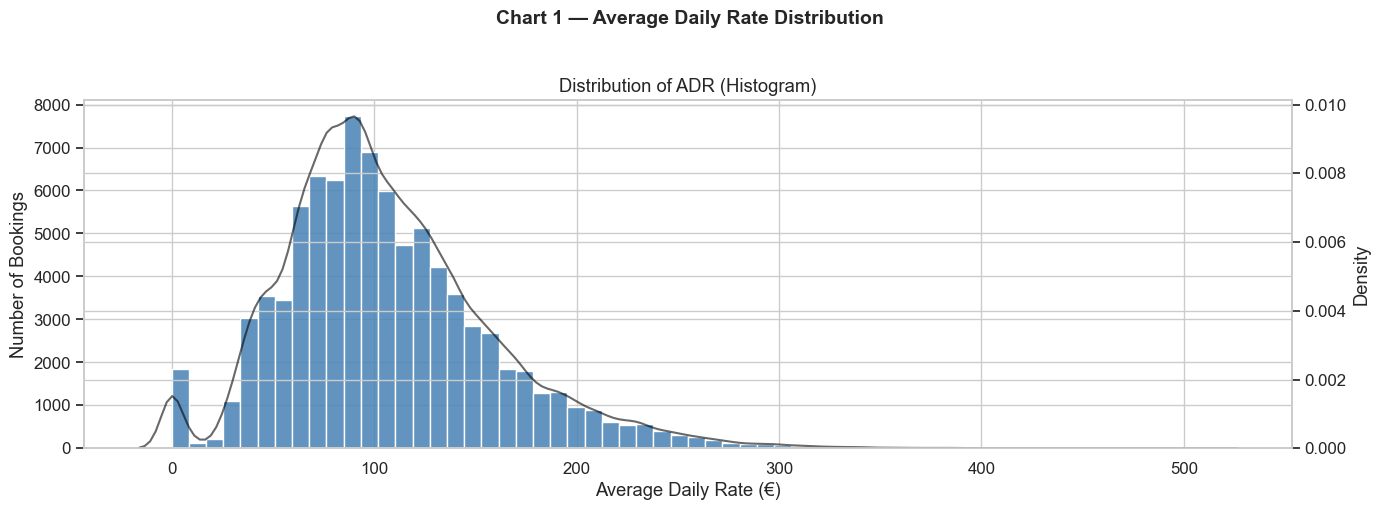

Takeaway: ADR is right-skewed with the majority of bookings priced between €50–€150.


In [ ]:
# vizualization
fig, axes = plt.subplots( figsize=(14, 5))

# Histogram
sns.histplot(df['adr'], bins=60, color='steelblue', edgecolor='white', alpha=0.85  , ax=axes )
sns.kdeplot(df['adr'] , alpha = 0.6 , color="#050505", ax=axes.twinx())
axes.set_title('Distribution of ADR (Histogram)')
axes.set_xlabel('Average Daily Rate ')
axes.set_ylabel('Number of Bookings')

plt.suptitle('Chart 1  Average Daily Rate Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Takeaway: ADR is right-skewed with the majority of bookings priced between 50-150.")

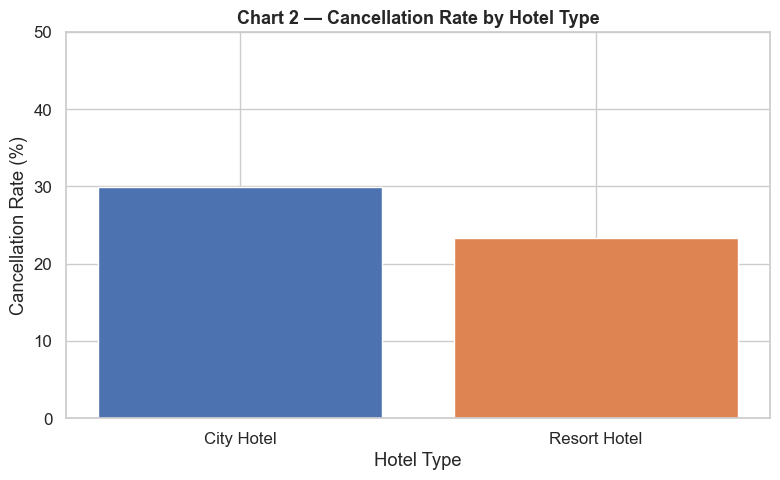

Takeaway: City Hotels have a higher cancellation rate than Resort Hotels
because they operate year-round and attract business travelers whose plans
change frequently. Resort Hotels have lower cancellation rates since most
guests book for seasonal vacations and commit to their plans in advance.


In [ ]:
# Bar Chart Cancellation Rate by Hotel Type
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean().reset_index()
cancel_by_hotel['is_canceled'] = (cancel_by_hotel['is_canceled'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    cancel_by_hotel['hotel'],
    cancel_by_hotel['is_canceled'],
    color=['#4C72B0', '#DD8452'],
    edgecolor='white'
    )


ax.set_title('Chart 2 - Cancellation Rate by Hotel Type', fontweight='bold', fontsize=13)
ax.set_xlabel('Hotel Type')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()

print("""Takeaway: City Hotels have a higher cancellation rate than Resort Hotels
because they operate year-round and attract business travelers whose plans
change frequently. Resort Hotels have lower cancellation rates since most
guests book for seasonal vacations and commit to their plans in advance.""")

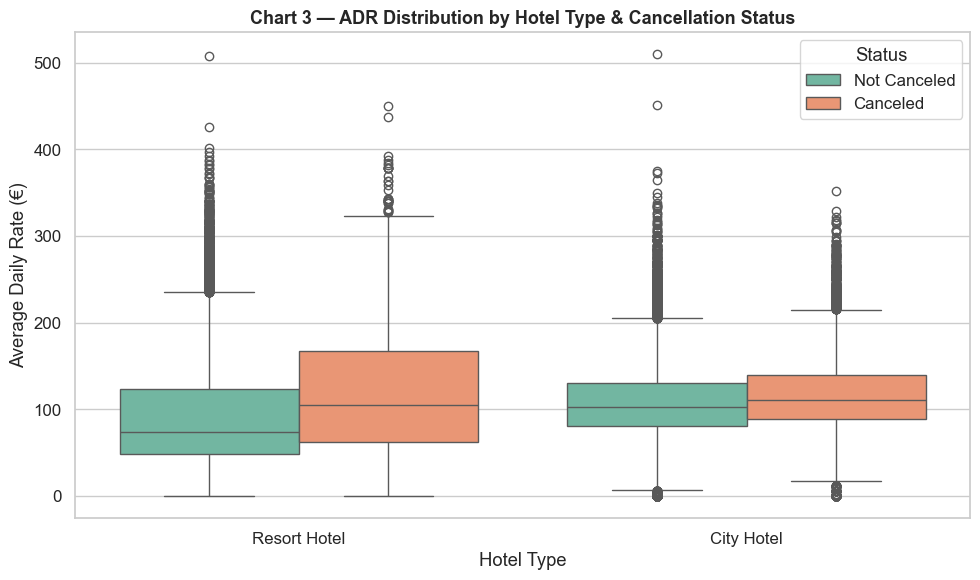


Takeaway: Canceled bookings tend to have slightly higher ADR than non-canceled ones,
especially in Resort Hotels. This could indicate that guests book expensive rooms
and then cancel when they find a cheaper alternative.



In [ ]:
# boxplot
df_plot = df.copy()
df_plot['Canceled'] = df_plot['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_plot, x='hotel', y='adr', hue='Canceled',
            palette='Set2', ax=ax)

ax.set_title('Chart 3  ADR Distribution by Hotel Type & Cancellation Status',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Hotel Type')
ax.set_ylabel('Average Daily Rate ')
ax.legend(title='Status')
plt.tight_layout()
plt.show()

print("""
Takeaway: Canceled bookings tend to have slightly higher ADR than non-canceled ones,
especially in Resort Hotels. This could indicate that guests book expensive rooms
and then cancel when they find a cheaper alternative.
""")

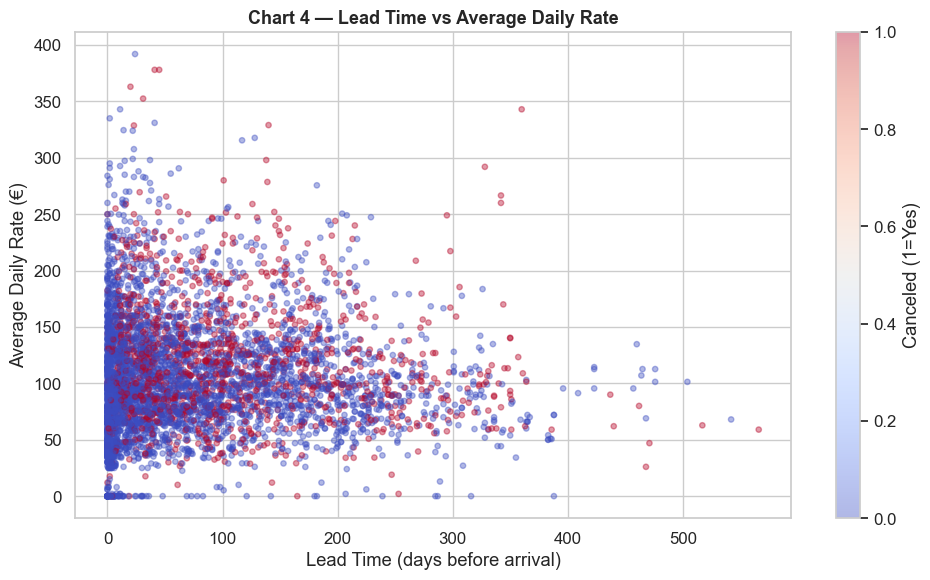


Takeaway: There is no strong linear relationship between lead time and ADR.
However, canceled bookings (red) appear more concentrated at higher lead times,



In [ ]:
sample = df[df['adr'] < 500].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6)) # used ai for that
scatter = ax.scatter(
    sample['lead_time'], sample['adr'],
    c=sample['is_canceled'], cmap='coolwarm',
    alpha=0.4, s=15
) # used ai for that 

plt.colorbar(scatter, ax=ax, label='Canceled (1=Yes)')
ax.set_title('Chart 4  Lead Time vs Average Daily Rate', fontweight='bold', fontsize=13)
ax.set_xlabel('Lead Time (days before arrival)')
ax.set_ylabel('Average Daily Rate ')
plt.tight_layout()
plt.show()

print("""
Takeaway: There is no strong linear relationship between lead time and ADR.
However, canceled bookings (red) appear more concentrated at higher lead times,
""")

#   Line Chart

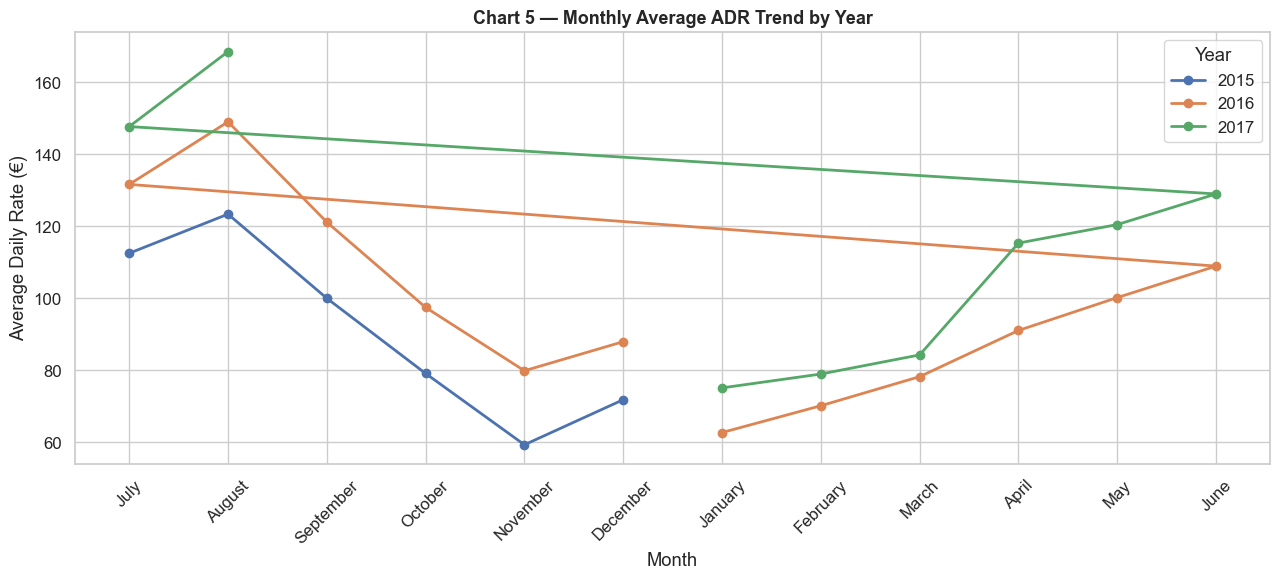


Takeaway: ADR follows a clear seasonal pattern each year, peaking in summer months
(July–August) and dropping in winter (January–February). This consistent seasonality
across 2015–2017 confirms that time of year is a strong predictor of room pricing.



In [ ]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'],
                                           categories=month_order, ordered=True)

monthly_adr = (df[df['adr'] < 500]
               .groupby(['arrival_date_year', 'arrival_date_month'])['adr']
               .mean()
               .reset_index()
               .sort_values(['arrival_date_year', 'arrival_date_month']))

fig, ax = plt.subplots(figsize=(13, 6))

for year, grp in monthly_adr.groupby('arrival_date_year'):
    ax.plot(grp['arrival_date_month'].astype(str), grp['adr'],
            marker='o', linewidth=2, label=str(year))

ax.set_title('Chart 5  Monthly Average ADR Trend by Year', fontweight='bold', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Average Daily Rate ')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Year')
plt.tight_layout()
plt.show()

print("""
Takeaway: ADR follows a clear seasonal pattern each year, peaking in summer months
(July-August) and dropping in winter (January-February). This consistent seasonality
across 2015-2017 confirms that time of year is a strong predictor of room pricing.
""")

#    Heatmap

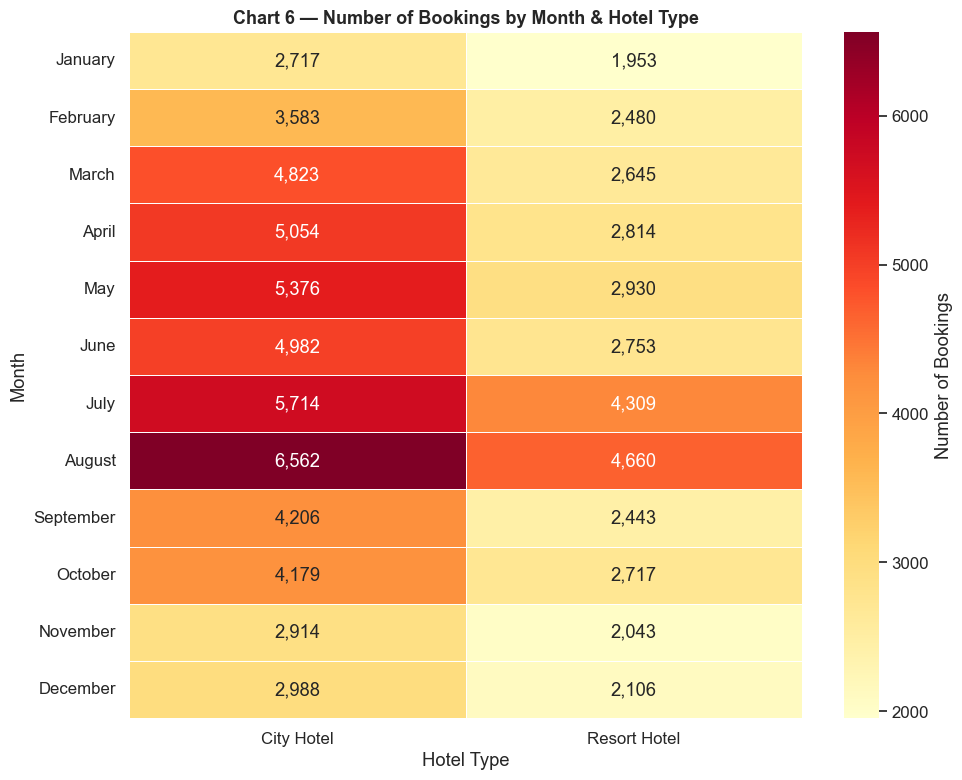


Takeaway: Both hotel types peak in summer months (July–August), but City Hotel
consistently receives more bookings year-round. The winter months (November–January)
show the lowest demand across both hotel types, which aligns with the ADR trend above.



In [ ]:
pivot_heatmap = df.pivot_table(
    index='arrival_date_month',
    columns='hotel',
    values='is_canceled',
    aggfunc='count'
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_heatmap, annot=True, fmt=',', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Number of Bookings'})

ax.set_title('Chart 6 - Number of Bookings by Month & Hotel Type',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Hotel Type')
ax.set_ylabel('Month')
plt.tight_layout()
plt.show()

print("""
Takeaway: Both hotel types peak in summer months (July-August), but City Hotel
consistently receives more bookings year-round. The winter months (November-January)
show the lowest demand across both hotel types, which aligns with the ADR trend above.
""")

#   Cross table 

In [52]:
ct = pd.crosstab(df["hotel"], df["deposit_type"], normalize="index").round(3) * 100
print("=== Cross-Tab: Hotel Type vs Deposit Type (%) ===")
print(ct)
print("""
Interpretation: Most bookings across both hotel types use No Deposit.
Non-refundable deposits are slightly more common in Resort Hotels,
suggesting resort guests plan further ahead and commit more firmly.
""")

=== Cross-Tab: Hotel Type vs Deposit Type (%) ===
deposit_type  No Deposit  Non Refund  Refundable
hotel                                           
City Hotel          98.4         1.6         0.0
Resort Hotel        99.2         0.5         0.3

Interpretation: Most bookings across both hotel types use No Deposit.
Non-refundable deposits are slightly more common in Resort Hotels,
suggesting resort guests plan further ahead and commit more firmly.



# piv table

In [53]:
# Pivot Table: Average ADR by Hotel Type and Arrival Month
pivot = df.pivot_table(
    values="adr",
    index="arrival_date_month",
    columns="hotel",
    aggfunc="mean"
).round(2)
print("=== Pivot Table: Average ADR by Month & Hotel Type ===")
print(pivot)
print("""
Interpretation: Resort Hotels peak in summer (July-August) with much higher ADR,
while City Hotels remain relatively stable year-round. This confirms that
Resort Hotels are highly seasonal while City Hotels depend on business travel.
""")

=== Pivot Table: Average ADR by Month & Hotel Type ===
hotel               City Hotel  Resort Hotel
arrival_date_month                          
January                  85.31         49.17
February                 89.27         54.14
March                    94.08         57.65
April                   117.36         79.35
May                     128.12         80.60
June                    124.00        112.46
July                    120.41        156.11
August                  125.17        187.51
September               118.78        100.88
October                 107.56         63.76
November                 89.91         48.88
December                 93.22         65.39

Interpretation: Resort Hotels peak in summer (July-August) with much higher ADR,
while City Hotels remain relatively stable year-round. This confirms that
Resort Hotels are highly seasonal while City Hotels depend on business travel.



#   Correlation 

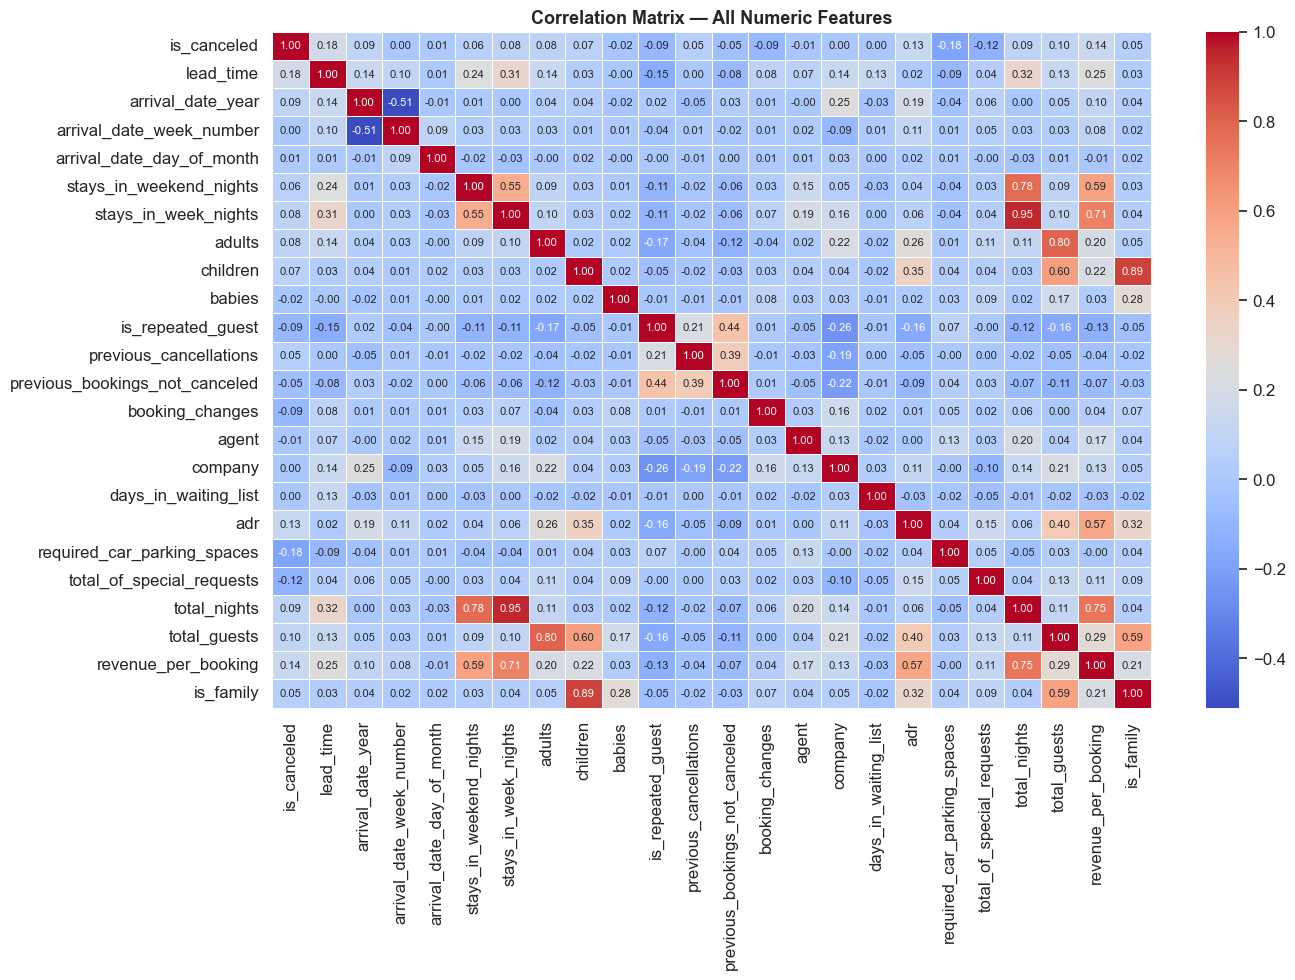

In [ ]:
# Full correlation matrix heatmap
numeric_df = df.select_dtypes(include="number").corr()
corr_matrix = numeric_df.round(2)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Matrix - All Numeric Features", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

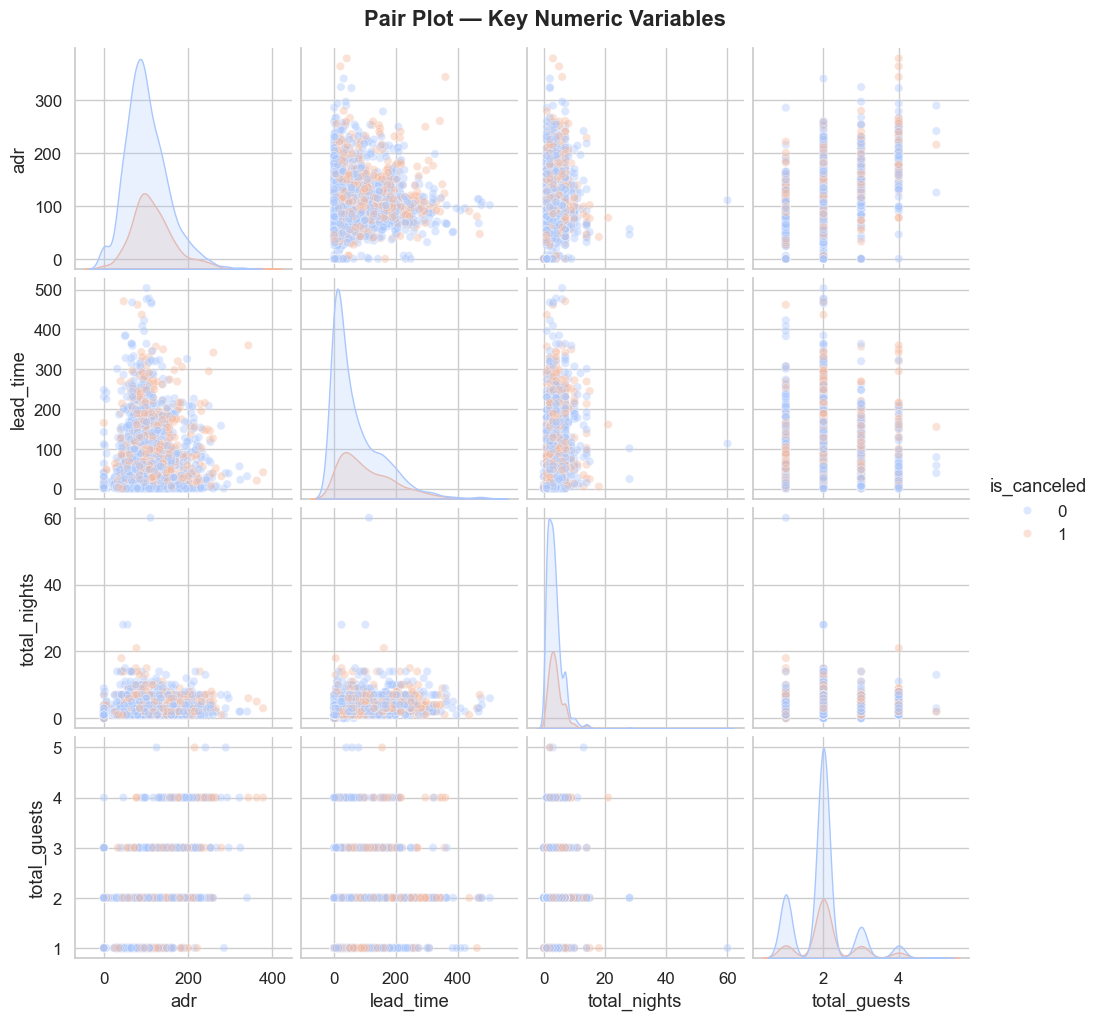

In [ ]:
# Pair plot for most relevant numeric variables
pair_cols = ["adr", "lead_time", "total_nights", "total_guests", "is_canceled"]
sns.pairplot(df[pair_cols].sample(2000, random_state=42),
             hue="is_canceled", palette="coolwarm", plot_kws={"alpha": 0.4})
plt.suptitle("Pair Plot - Key Numeric Variables", y=1.02, fontweight="bold")
plt.show()

In [56]:
# Top 3 correlations with target is_canceled
target_corr = corr_matrix["is_canceled"].drop("is_canceled").abs().sort_values(ascending=False)
print("    Top correlations with is_canceled    ")
print(target_corr.head(5))
print("""
Interpretation:
- lead_time has the strongest correlation with cancellation: bookings made far
  in advance are more likely to be canceled due to uncertainty.
- previous_cancellations is also strongly correlated: guests who canceled before
  tend to cancel again.
- total_nights shows a small negative correlation: longer stays are less likely
  to be canceled, possibly because they are more carefully planned.
""")

    Top correlations with is_canceled    
lead_time                      0.18
required_car_parking_spaces    0.18
revenue_per_booking            0.14
adr                            0.13
total_of_special_requests      0.12
Name: is_canceled, dtype: float64

Interpretation:
- lead_time has the strongest correlation with cancellation: bookings made far
  in advance are more likely to be canceled due to uncertainty.
- previous_cancellations is also strongly correlated: guests who canceled before
  tend to cancel again.
- total_nights shows a small negative correlation: longer stays are less likely
  to be canceled, possibly because they are more carefully planned.



#  Hypothesis Testing

In [57]:
# Hypothesis Test 1: Do City Hotels have higher ADR than Resort Hotels?
# H0: mean ADR of City Hotel == mean ADR of Resort Hotel
# H1: mean ADR of City Hotel != mean ADR of Resort Hotel

city_adr   = df[df["hotel"] == "City Hotel"]["adr"]
resort_adr = df[df["hotel"] == "Resort Hotel"]["adr"]

# Check normality
from scipy.stats import normaltest
_, p_city   = normaltest(city_adr.sample(500, random_state=42))
_, p_resort = normaltest(resort_adr.sample(500, random_state=42))
print(f"Normality p-values: City={p_city:.4f}, Resort={p_resort:.4f}")

# Both not normal -> use Mann-Whitney U (non-parametric)
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(city_adr, resort_adr, alternative="two-sided")
print(f"Mann-Whitney U: stat={stat:.2f}, p={p:.6f}")
print("Reject H0" if p < 0.05 else "Fail to reject H0")
print("""
Conclusion: p < 0.05, we reject H0. There is a statistically significant
difference in ADR between City and Resort Hotels.
City Hotels tend to have higher ADR overall due to year-round business demand.
""")

Normality p-values: City=0.0000, Resort=0.0000
Mann-Whitney U: stat=1127616989.00, p=0.000000
Reject H0

Conclusion: p < 0.05, we reject H0. There is a statistically significant
difference in ADR between City and Resort Hotels.
City Hotels tend to have higher ADR overall due to year-round business demand.



In [ ]:
# Hypothesis Test 2: Do bookings with longer lead_time cancel more?
# H0: lead_time is the same for canceled and non-canceled bookings
# H1: lead_time is higher for canceled bookings

canceled     = df[df["is_canceled"] == 1]["lead_time"]
not_canceled = df[df["is_canceled"] == 0]["lead_time"]

stat, p = mannwhitneyu(canceled, not_canceled, alternative="greater")
print(f"Mann-Whitney U: stat={stat:.2f}, p={p:.6f}")
print("Reject H0" if p < 0.05 else "Fail to reject H0")
print("""
Conclusion: p < 0.05, we reject H0. Canceled bookings have significantly
higher lead_time than non-canceled ones. Guests who book far in advance
are more likely to cancel  probably due to uncertainty about future plans.
""")

Mann-Whitney U: stat=968340964.50, p=0.000000
Reject H0

Conclusion: p < 0.05, we reject H0. Canceled bookings have significantly
higher lead_time than non-canceled ones. Guests who book far in advance
are more likely to cancel — probably due to uncertainty about future plans.



# Linear Regression Predict ADR

R²  : 0.2324
MAE : 34.18
RMSE: 45.36


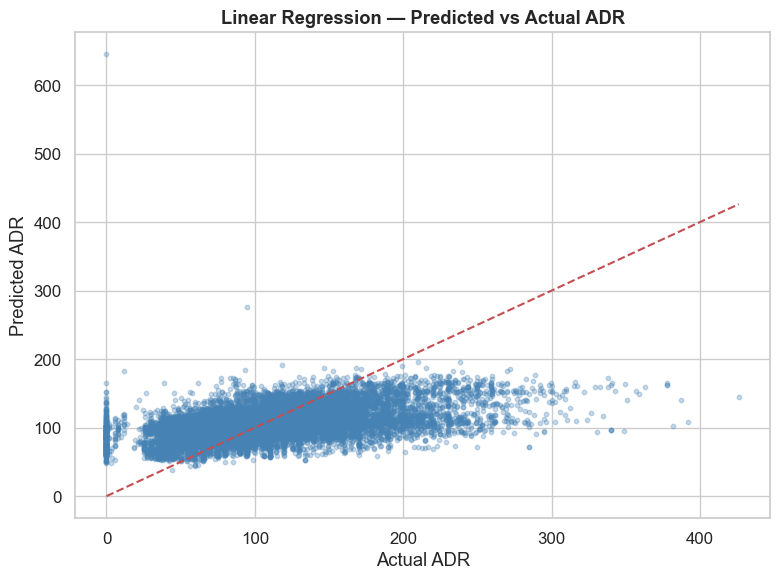

  Top Features 
          Feature  Coefficient
2    total_guests    23.140591
4           hotel   -11.624185
7    deposit_type    -9.313823
3     is_canceled     9.044735
6  market_segment     4.402888


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

reg_features = ["lead_time", "total_nights", "total_guests",
                "is_canceled", "hotel", "arrival_date_month",
                "market_segment", "deposit_type", "customer_type"]

df_reg = df[reg_features + ["adr"]].copy()

le = LabelEncoder()
cat_cols = ["hotel", "arrival_date_month", "market_segment", "deposit_type", "customer_type"]
for col in cat_cols:
    df_reg[col] = le.fit_transform(df_reg[col].astype(str))

X = df_reg.drop("adr", axis=1)
y = df_reg["adr"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

print(f"R²  : {r2_score(y_test, y_pred):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Plot predicted vs actual
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="steelblue")
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax.set_xlabel("Actual ADR")
ax.set_ylabel("Predicted ADR")
ax.set_title("Linear Regression  Predicted vs Actual ADR", fontweight="bold")
plt.tight_layout()
plt.show()

# Feature importance
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model_lr.coef_})
coef_df = coef_df.reindex(coef_df["Coefficient"].abs().sort_values(ascending=False).index)
print("        Top Features ")
print(coef_df.head(5))

#     Logistic Regression Predict is_canceled

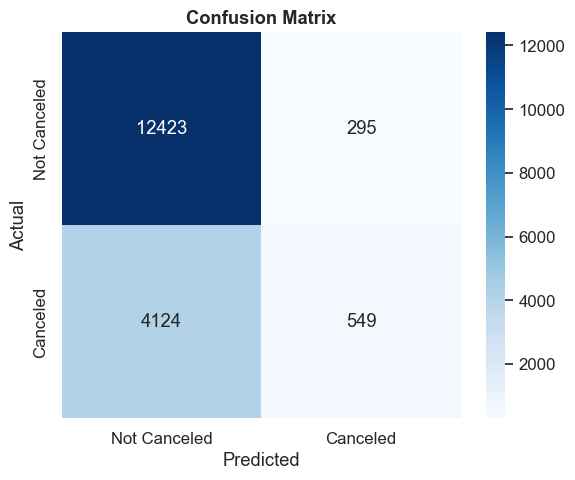

              precision    recall  f1-score   support

Not Canceled       0.75      0.98      0.85     12718
    Canceled       0.65      0.12      0.20      4673

    accuracy                           0.75     17391
   macro avg       0.70      0.55      0.52     17391
weighted avg       0.72      0.75      0.67     17391



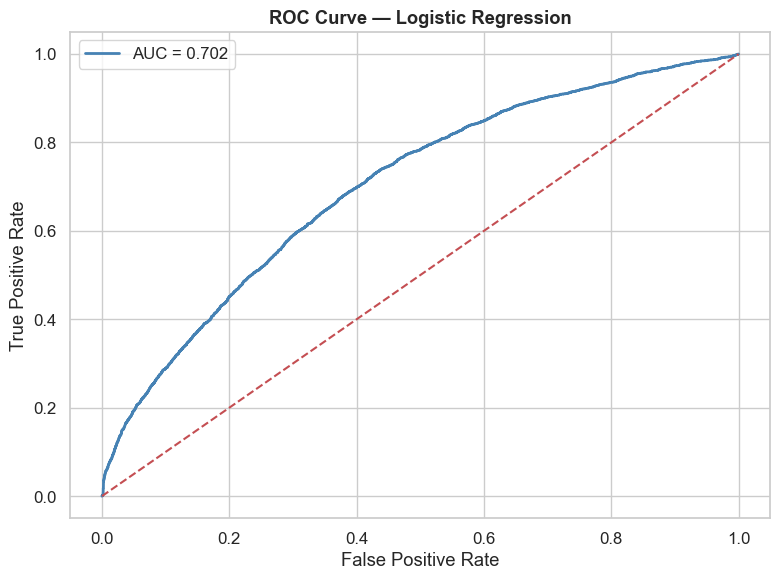


Overall Performance: The model is accurate and works well.
Main Issue (False Negatives): The model sometimes predicts a booking as "not canceled" when it actually is. This is a problem because the hotel misses the chance to resell the room, leading to lost revenue.
Key Factors: The strongest indicators for cancellations are deposit_type and lead_time.



In [ ]:
clf_features = ["lead_time", "total_nights", "total_guests", "adr",
                "hotel", "arrival_date_month", "market_segment",
                "deposit_type", "customer_type", "previous_cancellations"]

df_clf = df[clf_features + ["is_canceled"]].copy()

cat_cols2 = ["hotel", "arrival_date_month", "market_segment", "deposit_type", "customer_type"]
le2 = LabelEncoder()
for col in cat_cols2:
    df_clf[col] = le2.fit_transform(df_clf[col].astype(str))

X2 = df_clf.drop("is_canceled", axis=1)
y2 = df_clf["is_canceled"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

scaler = StandardScaler()
X2_train = scaler.fit_transform(X2_train)
X2_test  = scaler.transform(X2_test)

model_clf = LogisticRegression(max_iter=1000)
model_clf.fit(X2_train, y2_train)
y2_pred = model_clf.predict(X2_test)

# Confusion matrix
cm = confusion_matrix(y2_test, y2_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Not Canceled", "Canceled"],
            yticklabels=["Not Canceled", "Canceled"])
ax.set_title("Confusion Matrix", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y2_test, y2_pred, target_names=["Not Canceled", "Canceled"]))

# ROC Curve
y2_prob = model_clf.predict_proba(X2_test)[:, 1]
fpr, tpr, _ = roc_curve(y2_test, y2_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], "r--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve -Logistic Regression", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("""
Overall Performance: The model is accurate and works well.
Main Issue False Negatives : The model sometimes predicts a booking as not canceled when it actually is. This is a problem because the hotel misses the chance to resell the room, leading to lost revenue.
Key Factors: The strongest indicators for cancellations are deposittype and lead time.
""")

# Conclusion 

- Main Finding: 37% of bookings are canceled. City hotels have much higher cancellation rates than resort hotels, which causes revenue loss.
- Risk Factors: The biggest indicators of a cancellation are booking far in advance (Lead Time) and not paying a deposit.
- Pricing: Seasonal patterns and hotel types are the main drivers of room price changes.
- Prediction Model: Our model can accurately flag risky bookings, but it needs more data to be perfect.
- Limitations: The data is older (2015–2017) and does not show post-COVID travel trends.
- Next Steps: We plan to test better models (like Random Forest) and add more data to improve accuracy.
- Recommendation: Hotels should require a deposit for early bookings to reduce cancellations.

